# YbF


This is aiming to reproduce and understand the results from [An ultracold molecular beam for testing fundamental physics](https://iopscience.iop.org/article/10.1088/2058-9565/ac107e)

## Loading packages

In [1]:
using Pkg
Pkg.activate("/Users/jose/Documents/Works/MIT/RaX/Simu/Molecule-Sims/")
using
    Revise,
    QuantumStates,            # for calculating molecular structure
    OpticalBlochEquations,    # for solving optical Bloch equations
    UnitsToValue,              # for numerical values
    DifferentialEquations, # for differential equations (with
    Plots,                    # for plotting
    PlotlyJS,              # for interactive plots
    Statistics,              # for statistics
    LinearAlgebra,       # for linear algebra
    StaticArrays,        # for static arrays
    DataFrames           # for data frames
;

  Activating project at `~/Documents/Works/MIT/RaX/Simu/Molecule-Sims`


Let us define some helper functions and a constant for renormalizing.

In [2]:
# Get the basis element with the maximum coefficient from the state
function get_max_coeff_basis_element(state)
    coeffs = abs.(state.coeffs) .^ 2
    max_idx = argmax(coeffs)
    return state.basis[max_idx]
end

# Extract quantum numbers from the basis element with the maximum coefficient
function extract_quantum_numbers_from_state(state)
    basis_elem = get_max_coeff_basis_element(state)
    quantum_numbers = Dict(:N => basis_elem.N, :J => basis_elem.J, :F => basis_elem.F, :M => basis_elem.M)
    return quantum_numbers
end

# Get the J quantum number from the basis element with the maximum coefficient
function get_J_quantum_number(state)
    basis_elem = get_max_coeff_basis_element(state)
    return basis_elem.J
end

# Search for a state in a list of states by specific quantum numbers
function find_state_by_quantum_numbers(states, N, J, F, M)
    for state in states
        qn = extract_quantum_numbers_from_state(state)
        if qn[:N] == N && qn[:J] == J && qn[:F] == F && qn[:M] == M
            return state
        end
    end
    error("State with quantum numbers N=$N, J=$J, F=$F, M=$M not found.")
end
function all_state_info(state)
    basis_elem = get_max_coeff_basis_element(state)
    return basis_elem
end

_μB = (μB / h) * 1e-4;

# Problem setup

## Defining the energy structure

### Ground state Hamiltonian for the $X^2\Sigma^+(N=1)$

Includes defining a magnetic field given by $$\vec B = B_0 (0, 1/\sqrt{2}, 1/\sqrt{2})$$

In [3]:
# Quantum Number Bounds
# Define the quantum number bounds for the system. Here, S, I, Λ, and N represent
# the spin, nuclear spin, projection of the electronic orbital angular momentum
# along the molecular axis, and the rotational quantum number, respectively.
QN_bounds = (
    S = 1/2,           # Spin quantum number
    I = 1/2,           # Nuclear spin quantum number
    Λ = 0,             # Projection of the electronic orbital angular momentum
    N = 0:3            # Rotational quantum number range
)

# Generate all possible quantum states for a Hund's case (b) linear molecule
X_state_basis = enumerate_states(HundsCaseB_LinearMolecule, QN_bounds)

# Define the Hamiltonian Operator
X_state_operator = :(
    BX * Rotation +                     # Rotational energy term
    DX * RotationDistortion +           # Rotational distortion energy term
    γX * SpinRotation +                 # Spin-rotation interaction term
    bFX * Hyperfine_IS +                # Hyperfine interaction (Fermi contact term)
    cX * (Hyperfine_Dipolar / 3)        # Hyperfine interaction (dipolar term)
)

# Define the Parameters for the Hamiltonian
# These parameters are specific to the YbF molecule and are given in Hertz (Hz).
X_state_parameters = QuantumStates.@params begin
    BX = 7233.8271e6         # Rotational constant in Hz
    DX = 0.                  # Rotational distortion constant in Hz (set to 0 for simplicity)
    γX = -13.41679e6         # Spin-rotation interaction constant in Hz
    bFX = 170.26374e6        # Fermi contact term in Hz
    cX = 85.4028e6           # Dipolar hyperfine interaction constant in Hz
end

# Create the Hamiltonian
# Combine the basis states, operator, and parameters to define the Hamiltonian.
X_state_ham = Hamiltonian(basis=X_state_basis, operator=X_state_operator, parameters=X_state_parameters)

# Define Zeeman Terms
# The Zeeman effect describes how energy levels are split in the presence of a magnetic field.
# Add Zeeman terms

B = 25.0 * 1e-4 # 10 Gau

# Add Zeeman terms
Zeeman_x(state, state′) = (Zeeman(state, state′,-1) - Zeeman(state, state′,1))/sqrt(2)
Zeeman_y(state, state′) = im*(Zeeman(state, state′,-1) + Zeeman(state, state′,1))/sqrt(2)
Zeeman_z(state, state′) = Zeeman(state, state′, 0)

X_state_ham = add_to_H(X_state_ham, :B_x, (gS * _μB * 1e-6) * Zeeman_x)
X_state_ham = add_to_H(X_state_ham, :B_y, (gS * _μB * 1e-6) * Zeeman_y)
X_state_ham = add_to_H(X_state_ham, :B_z, (gS * _μB * 1e-6) * Zeeman_z)
X_state_ham.parameters.B_x = 0.
X_state_ham.parameters.B_y = B / sqrt(2)
X_state_ham.parameters.B_z = B / sqrt(2)

# Evaluate and Solve the Hamiltonian
# Compute the energy levels and eigenstates of the Hamiltonian.
evaluate!(X_state_ham)
QuantumStates.solve!(X_state_ham)
all_grounds = X_state_ham.states[5:16]
ground_states = [state for state in all_grounds if extract_quantum_numbers_from_state(state)[:N]== 1]


12-element Vector{State{HundsCaseB_LinearMolecule}}:
 State{HundsCaseB_LinearMolecule}(1.4339486824684109e10, HundsCaseB_LinearMolecule[HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 0, 0, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = 0.0:1.0:0.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 1, -1, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = -1.0:1.0:1.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 1, 0, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = -1.0:1.0:1.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 1, 1, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = -1.0:1.0:1.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 1, 1/2, 0, 0, (K = 0, N = 0:∞, J = 0.5:1.0:1.5, F = 0.0:1.0:1.0, M = 0.0:1.0:0.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 1, 1/2, 1, -1, (K = 0, N = 0:∞, J = 0.5:1.0:1.5, F = 0.0:1.0:1

### Create Hamiltonian for the $A^2\Pi_{1/2}(000, J=1/2+)$ state

In [4]:
QN_bounds = (
    S = 1/2,
    I = 1/2,
    Λ = (-1,1),
    J = 1/2:3/2 # ?
)
A_state_basis = enumerate_states(HundsCaseA_LinearMolecule, QN_bounds)

A_state_operator = :(
    T_A * DiagonalOperator +
    Be_A * Rotation +
    Aso_A * SpinOrbit +
    q_A * ΛDoubling_q +
    p_A * ΛDoubling_p2q +
    a * Hyperfine_IL +
    d * Hyperfine_Dipolar_d
)

# Spectroscopic constants for CaOH, A state
A_state_parameters = QuantumStates.@params begin
    T_A = 542.8102*10^12 # Diagonal constant (electrion zero point energy)
    Be_A = 40.9304*10^12 # Rotational constant
    Aso_A = 7.4276*10^9  # A spin-orbit constant
    p_A = 11.882*10^9
    q_A = 0
    a = -0.8e6
    d = -4.6e6
end

A_state_ham = Hamiltonian(basis=A_state_basis, operator=A_state_operator, parameters=A_state_parameters)
evaluate!(A_state_ham)
QuantumStates.solve!(A_state_ham)
;
# Now we can convert it to HundsCaseB
excited_states = A_state_ham.states[1:4]
QN_bounds = (
    S = 1/2,
    I = 1/2,
    Λ = (-1,1),
    N = 0:3
)
A_state_basis = enumerate_states(HundsCaseB_LinearMolecule, QN_bounds)
excited_states = convert_basis(excited_states, A_state_basis)
# Just verify that the conversion was successful by checking the quantum numbers of the states
# We should only have J=1/2 for this case.
[extract_quantum_numbers_from_state(state) for state in excited_states]

4-element Vector{Dict{Symbol, HalfIntegers.Half{Int64}}}:
 Dict(:N => 1, :F => 1, :J => 1/2, :M => 1)
 Dict(:N => 1, :F => 1, :J => 1/2, :M => 0)
 Dict(:N => 1, :F => 1, :J => 1/2, :M => -1)
 Dict(:N => 1, :F => 0, :J => 1/2, :M => 0)

In [5]:
# Initialize matrices to store dipole moments
d = zeros(ComplexF64, 16, 16, 3)    # Matrix to store all dipole moments (16x16 matrix for 3 components)
d_ge = zeros(ComplexF64, 12, 4, 3)  # Matrix to store dipole moments between ground and excited states (12x4 matrix for 3 components)

# Compute transition dipole moments between two bases
# basis_tdms stores the transition dipole moments between the ground and excited state bases
basis_tdms = get_tdms_two_bases(X_state_ham.basis, A_state_basis, TDM)

# Calculate transition dipole moments between specific states
# This function fills the d_ge matrix with the dipole moments between the ground_states and excited_states
tdms_between_states!(d_ge, basis_tdms, ground_states, excited_states)

# Assign the calculated dipole moments to the appropriate submatrix in d
# The ground to excited state transitions are stored in the upper right submatrix of d
d[1:12, 13:16, :] .= d_ge;



In [6]:
states = [ground_states; excited_states]
n_excited = length(excited_states)

# for state ∈ states
#     state.E *= 1e6
# end
;

In [7]:
# A few constants used for the simulation
λ = 552e-9 # Wavelength of light in meters
Γ = 2π * 5.7e6
m = @with_unit 191 "u" # Mass of the molecule in atomic mass units
k = 2π / λ
δJ12 = +6*Γ # Detuning for J=1/2 state
;

In [8]:
# source states
g_interest_states = [state for state in all_grounds if (all_state_info(state).v_1 == 0 && all_state_info(state).v_2 == 0 && all_state_info(state).v_3 == 0)][1:4]
input_energies = [energy(st) for st in g_interest_states]
# Target states
a_qns =[extract_quantum_numbers_from_state(st) for st in excited_states][1]
energies = [energy(st) for st in excited_states]
# sorted
target_states = sort(excited_states, by = energy)
target_energy = [energy(st) for st in excited_states][1];

In [9]:
delta_state_energies = target_energy .- input_energies
# J12_energies = [energy(s) for s in input_states][1]
A_energy = target_energy
ω_J12s = [2π * (A_energy - inp_e) + δJ12 for inp_e in input_energies]
ω_J12 = ω_J12s[1]
s_func(s) = (r,t) -> s
I_sat =  π*h*c*Γ/(3λ^3) / 10
s_J12 = s_func(100.0)
# Sidebands
ratios = [1, 1/2, 1/2, 0]
s_J12_sidebands = [s_func(ratio * 100.0) for ratio in ratios]
pol_J12 = σ⁺ # Polarization for J=1/2
polarizations = [pol_J12 for _ in 1:length(pol_J12)]
ϵ(ϵ_val) = t -> ϵ_val;

Now, we need to define the laser... for this setup, I will define two scenarios... One single frequency (lowest energy transition in nu=0) and the complete case considering the sidebands as presented in the paper.

In [10]:
use_single_state = false
if use_single_state

    # Define the wave vectors and polarizations for the lasers in the XY‖ configuration
    k̂ = +x̂; ϵ1 = ϵ(rotate_pol(pol_J12, ẑ)); laser1 = Field(k̂, ϵ1, ω_J12, s_J12)
    k̂ = -x̂; ϵ2 = ϵ(rotate_pol(pol_J12, -ẑ)); laser2 = Field(k̂, ϵ2, ω_J12, s_J12)
    k̂ = +ŷ; ϵ3 = ϵ(rotate_pol(pol_J12, ẑ)); laser3 = Field(k̂, ϵ3, ω_J12, s_J12)
    k̂ = -ŷ; ϵ4 = ϵ(rotate_pol(pol_J12, -ẑ)); laser4 = Field(k̂, ϵ4, ω_J12, s_J12)

    lasers_XY_parallel = [laser1, laser2, laser3, laser4]
    # Define the wave vectors and polarizations for the lasers in the XY⊥ configuration
    k̂ = +x̂; ϵ1 = ϵ(rotate_pol(pol_J12, ŷ)); laser1 = Field(k̂, ϵ1, ω_J12, s_J12)
    k̂ = -x̂; ϵ2 = ϵ(rotate_pol(pol_J12, -ŷ)); laser2 = Field(k̂, ϵ2, ω_J12, s_J12)
    k̂ = +ŷ; ϵ3 = ϵ(rotate_pol(pol_J12, ẑ)); laser3 = Field(k̂, ϵ3, ω_J12, s_J12)
    k̂ = -ŷ; ϵ4 = ϵ(rotate_pol(pol_J12, -ẑ)); laser4 = Field(k̂, ϵ4, ω_J12, s_J12)

    lasers_XY_perpendicular = [laser1, laser2, laser3, laser4];
else

    lasers_plus_x = [Field(+x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_minus_x = [Field(-x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_plus_y = [Field(+ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_minus_y = [Field(-ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_XY_parallel = [lasers_plus_x; lasers_minus_x; lasers_plus_y; lasers_minus_y]

    laser_plus_x = [Field(+x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ŷ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    laser_minus_x = [Field(-x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ŷ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    laser_plus_y = [Field(+ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    laser_minus_y = [Field(-ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_XY_perpendicular = [laser_plus_x; laser_minus_x; laser_plus_y; laser_minus_y];
end

12-element Vector{Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}}:
 Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}([1.0, 0.0, 0.0], var"#35#36"{SVector{3, ComplexF64}}(ComplexF64[-0.5 - 6.123233995736766e-17im, 4.3297802811774664e-17 - 0.7071067811865476im, 0.5000000000000001 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 3.6675998146209235e15, var"#29#30"{Float64}(100.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}([1.0, 0.0, 0.0], var"#35#36"{SVector{3, ComplexF64}}(ComplexF64[-0.5 - 6.123233995736766e-17im, 4.3297802811774664e-17 - 0.7071067811865476im, 0.5000000000000001 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 3.6675998146209235e15, var"#29#30"{Float64}(50.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30

In [11]:
lasers = lasers_XY_parallel

12-element Vector{Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}}:
 Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}([1.0, 0.0, 0.0], var"#35#36"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 3.6675998146209235e15, var"#29#30"{Float64}(100.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}([1.0, 0.0, 0.0], var"#35#36"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 3.6675998146209235e15, var"#29#30"{Float64}(50.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#35#36"{SVector{3, ComplexF64}}, var"#29#30"{Float64}}([1.0, 0.0, 0.0], var"#35#36"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.

The OBE solver requires a set of parameters `p`, which are defined using the function `obe`. Most of these arguments should be self-explanatory, but a few require special attention:
* `freq_res` _(type: Float64)_: The resolution used when rounding frequencies (and the velocity) in order to ensure that the OBEs reach a quasi-periodic steady state. Defined in units of Γ and typically set to 1e-1 (or 1e-2 for low velocities).
* `extra_p` _(type: NamedTuple)_: Allows the user to define a set of "extra" parameters that may be used during the simulation. This is mostly relevant in cases where we wish to solve the OBEs several times and we have some parameter that is changing between solves, e.g., we may need to update our TDMs if we want to solve the OBEs for a range of magnetic fields. In that case it's helpful to ensure that the solver has access to the underlying Hamiltonian, as well as any data structures we've defined to help in updating the TDMs.

In [12]:
# Set initial conditions
particle = OpticalBlochEquations.Particle()
ρ0 = zeros(ComplexF64, length(states), length(states))
names = [extract_quantum_numbers_from_state(st) for st in states]
string_names = ["|$(qn[:J]),  $(qn[:F]), $(qn[:M])>" for qn in names]
ρ0[1,1] = 1.0

freq_res = 1e-1
p = obe(ρ0, particle, states, lasers, d, true, true; λ=λ, Γ=Γ, freq_res=freq_res)
;

In [13]:
bounds_FWHMs = (1.5, 3.1)
mean_fw = mean(bounds_FWHMs)
function fwhm_to_rms(x)
    return x / (2 * sqrt(2 * log(2)))
end
rms_speed = fwhm_to_rms(mean_fw);

In [14]:
p.r0 = (0., 0., 0.0) #./ k
p.v = (0., 0., rms_speed) ./ (Γ / k)
p.v = round_vel(p.v, p.freq_res)
;

Finally, we define a time span for the solver (here in terms of the period defined by `freq_res`, which is given by `p.period`). The actual solving is performed using the `DifferentialEquations` package in Julia, so we load this here as well. This package requires a `prob` variable of type `ODEProblem`. The cell below shows the syntax for how this variable is created for the OBE solver.

After solving, we can plot the populations as a function of time, and the force averaged over one period can be found in `prob.p.force_last_period`. Note that the force output in the simulation has units ħkΓ.

In [15]:

t_end = 5p.period+1
tspan = (0., t_end)
prob = ODEProblem(ρ!, p.ρ0_vec, tspan, p)
times = range(0, t_end, 1_000)

cb = PeriodicCallback(reset_force!, p.period)
@time sol = DifferentialEquations.solve(prob, DP5(), callback=cb, reltol=1e-3, saveat=times)

# Print the force
print("Force (10³ m/s): ", prob.p.force_last_period * (1e-3 * ħ * k * Γ / m));


 10.307274 seconds (12.86 M allocations: 828.720 MiB, 3.40% gc time, 79.53% compilation time)
Force (10³ m/s): [-2.005260992123479, -2.005260992123479, 0.0]

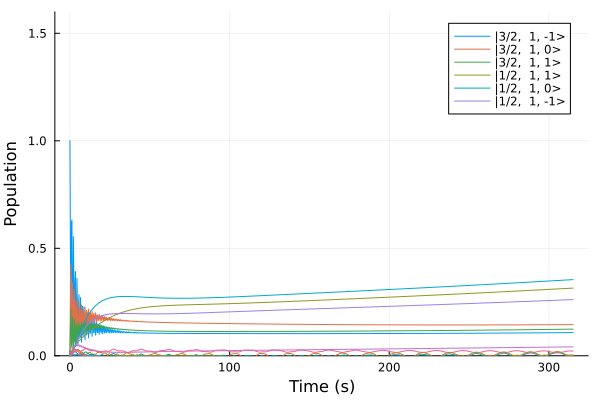

In [16]:
plot_us = sol.u
plot_ts = sol.t

n_states = size(p.ρ_soa, 1)
Plots.plot(
    ylim=(-0.0, 1.6),
)
for i in 1:n_states
    state_idx = n_states*(i-1) + i # For the diagonal elements
    # Only label if the state has u>0.1
    if maximum([real(u[state_idx]) for u in plot_us]) > 0.1
        Plots.plot!(plot_ts, [real(u[state_idx]) for u in plot_us], label=string_names[i])
    else
        Plots.plot!(plot_ts, [real(u[state_idx]) for u in plot_us], label=false)
    end
end
# Add the correct axis labels
Plots.plot!(
    xlabel="Time (s)",
    ylabel="Population"
)
# Add the legends to each plot


In [17]:
pop_df = []
for i in 1:length(string_names)
    _df = DataFrame(
        time = plot_ts,
        population = [real(u[n_states*(i-1) + i]) for u in plot_us],
        state = string_names[i]
    )
    push!(pop_df, _df)
end
pop_df = vcat(pop_df...);

In [18]:
plot_plotly = false
if plot_plotly
    unique_states = unique(pop_df.state)
    color_map = Dict{String, RGB}()
    for (i, state) in enumerate(unique_states)
        color_map[state] = RGB(convert(Color, HSL(360 * (i - 1) / length(unique_states), 1.0, 0.5)))
    end
    traces = AbstractTrace[]  # Initialize as an empty array of AbstractTrace
    for state in unique_states
        push!(traces, PlotlyJS.scatter(
            x = pop_df.time[pop_df.state .== state],
            y = pop_df.population[pop_df.state .== state],
            mode = "lines",
            text = pop_df.state[pop_df.state .== state],
            hoverinfo = "text",
            name = "Population: $state",
            line = attr(color=PlotlyBase.Colors.hex(color_map[state]))
        ))
    end
    layout = Layout(title="Population over Time by State", xaxis_title="Time", yaxis_title="Population")
    plot = Plot(traces, layout)
    display(plot)
end


# Replicating results with a simple run

In [19]:
using
    StaticArrays,
    RectiGrids,
    StatsBase

In [31]:
function prob_func!(prob, scan_values_grid, i)
    p = prob.p
    p.v .= (0, scan_values_grid[i].v, 0)
    p.v .= round_vel(p.v, p.freq_res)
    p.r0 .= scan_values_grid[i].r
    return prob
end
function output_func(p, sol)
    f = p.force_last_period
    return (f[1], f[2], f[3])
end
;
freq_res = 1e-1
p = obe(ρ0, particle, states, lasers, d, true, true; λ=λ, Γ=Γ, freq_res=freq_res)

t_end = 5p.period+1; tspan = (0., t_end)
@time prob = ODEProblem(ρ!, p.ρ0_vec, tspan, p, reltol=1e-3, save_on=false)

di = 2
rs = vcat([(n1/(di+1), n2/(di+1), n3/(di+1)) .* 2π for n1 ∈ 0:di, n2 ∈ 0:di, n3 ∈ 0:di]...)
vs = 0.:.5:3

scan_values = (r = rs, v = vs)
scan_values_grid = RectiGrids.grid(scan_values)
@time forces, populations = force_scan_v2(prob, scan_values_grid, prob_func!, output_func);
;


  0.000082 seconds (99 allocations: 4.594 KiB)


Progress: 100%|█████████████████████████████████████████| Time: 0:04:28


268.256667 seconds (134.01 k allocations: 29.458 MiB, 0.01% gc time, 0.04% compilation time: 100% of which was recompilation)


In [34]:
averaged_forces = []
@time for (i,v) ∈ enumerate(vs)
    idxs = [j for (j,x) ∈ enumerate(scan_values_grid) if x.v == v]
    _forces = [f[2] for f in forces[idxs] if abs(f[2]) <= 1e3]
    push!(averaged_forces, mean([f for f in _forces]))
end

  0.105397 seconds (84.63 k allocations: 5.696 MiB, 98.76% compilation time)


In [36]:
averaged_forces = []
stds = []
@time for (i,v) ∈ enumerate(vs)
    idxs = [j for (j,x) ∈ enumerate(scan_values_grid) if x.v == v]
    _forces = [f[2] for f in forces[idxs] if abs(f[2]) <= 1e3]
    push!(averaged_forces, mean([f for f in _forces]))
    push!(stds, std([f for f in _forces]))
end
Plots.plot(vs, (1e-3 * ħ * k * Γ / m) .* averaged_forces,
    xlabel="Velocity (m/s)",
    ylabel="a (10³ m/s²)",
    title="Force profile",
    framestyle=:box,
    linewidth=2.5,
    legend=nothing
    )
Plots.errorbar!(vs, (1e-3 * ħ * k * Γ / m) .* averaged_forces, yerr=(1e-3 * ħ * k * Γ / m) .* stds, linewidth=2.5)


  0.110838 seconds (84.66 k allocations: 5.697 MiB, 98.37% compilation time)


UndefVarError: UndefVarError: `errorbar!` not defined